<a href="https://colab.research.google.com/github/Harshithpalan/Python-projects/blob/main/Neural%20Style%20Transfer%20App.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Style Transfer App 3A8

This notebook demonstrates how to use a pre-trained Neural Style Transfer model from [TensorFlow Hub](https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2).

In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
import PIL.Image

def load_img(path_to_img):
  max_dim = 512
  img = tf.io.read_file(path_to_img)
  img = tf.image.decode_image(img, channels=3)
  img = tf.image.convert_image_dtype(img, tf.float32)

  shape = tf.cast(tf.shape(img)[:-1], tf.float32)
  long_dim = max(shape)
  scale = max_dim / long_dim

  new_shape = tf.cast(shape * scale, tf.int32)

  img = tf.image.resize(img, new_shape)
  img = img[tf.newaxis, :]
  return img

def imshow(image, title=None):
  if len(image.shape) > 3:
    image = tf.squeeze(image, axis=0)

  plt.imshow(image)
  if title:
    plt.title(title)
  plt.axis('off')

### 1. Load Content and Style Images
We'll fetch two images: a content image (the photo you want to transform) and a style image (the artistic style you want to apply).

83281/83281 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
195196/195196 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


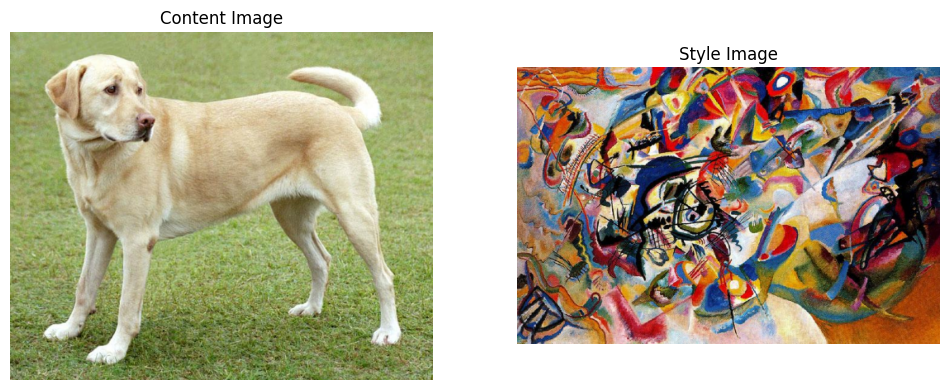

In [2]:
content_path = tf.keras.utils.get_file('YellowLabradorLooking_new.jpg', 'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg')
style_path = tf.keras.utils.get_file('kandinsky5.jpg','https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')

content_image = load_img(content_path)
style_image = load_img(style_path)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
imshow(content_image, 'Content Image')
plt.subplot(1, 2, 2)
imshow(style_image, 'Style Image')

### 2. Apply Neural Style Transfer
We use the Magenta model from TensorFlow Hub which supports arbitrary image stylization in a single forward pass.

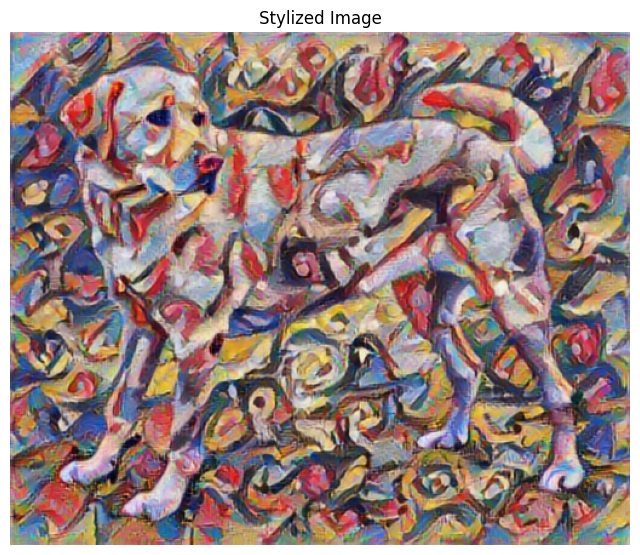

In [3]:
# Load the model from TF Hub
hub_model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')

# Stylize the image
stylized_image = hub_model(tf.constant(content_image), tf.constant(style_image))[0]

# Display the result
plt.figure(figsize=(8, 8))
imshow(stylized_image, 'Stylized Image')
plt.show()